In [92]:
import numpy as np

# Neumann Boundary Conditions (BCs)

## What is a Neumann Boundary Condition?

A Neumann boundary condition specifies the value of the derivative (gradient) of a variable at the boundary instead of specifying the value of the variable itself.

Mathematically,

    ∂u/∂x = g

where g is a known gradient.

The most common case is the zero-gradient condition:

    ∂u/∂x = 0

---

## Physical Meaning

A Neumann boundary condition controls the flux through the boundary.

Examples:

- Insulated wall in heat transfer
- Symmetry boundary
- Zero mass flux boundary
- No concentration gradient boundary

For a zero-gradient condition:

    ∂u/∂x = 0

there is no change in the solution normal to the boundary.

---

## Finite Difference Approximation

At the left boundary:

    ∂u/∂x ≈ (u₁ - u₀)/Δx

Applying

    ∂u/∂x = 0

gives

    (u₁ - u₀)/Δx = 0

Therefore

    u₀ = u₁

---

At the right boundary:

    ∂u/∂x ≈ (uN-1 - uN-2)/Δx

Applying

    ∂u/∂x = 0

gives

    uN-1 = uN-2

---

## Numerical Implementation

After updating all interior nodes:

```python
unew[0]  = unew[1]
unew[-1] = unew[-2]
```

This enforces

    ∂u/∂x = 0

at both boundaries.

---

## Application to the Advection-Diffusion Equation

The governing equation is

    ∂u/∂t + c∂u/∂x = μ∂²u/∂x²

The interior nodes are updated using

    uᵢⁿ⁺¹
    =
    uᵢⁿ
    - Co(uᵢⁿ-uᵢ₋₁ⁿ)
    + Fo(uᵢ₊₁ⁿ-2uᵢⁿ+uᵢ₋₁ⁿ)

where

    Co = cΔt/Δx

    Fo = μΔt/Δx²

The boundary nodes are then imposed separately:

```python
unew[0]  = unew[1]
unew[-1] = unew[-2]
```

---

## Complete Code Structure

```python
while t < tend:

    unew = np.zeros(nx)

    for i in range(1, nx-1):

        unew[i] = u[i] \
                  - co*(u[i]-u[i-1]) \
                  + fo*(u[i+1]-2*u[i]+u[i-1])

    # Neuma*n BC
    unew*0]  = unew[1]
    unew[-1] = unew[-2]

    u[:] = unew[:]

    sol.ap*end(u.copy())

    t += dt
```

--*

## Important Note

The initial c*ndition should satisfy the Neumann*BC.

For example,

    u(x,0) = co*(πx)

*s a good choice because

    ∂u/∂x*= -π sin(πx)

and

    ∂u/*x = 0

at both boundaries.

A sine*wave*

    u(x,0) = sin(2πx)

does*not satisfy

    ∂u/∂x = 0

*t the boundaries* so the solver immediately modifie* the solution near the edges.

---*
## Key Idea

Dirichlet BC:
    Fi*es the value.

    u = known*value

Neumann BC:
    Fixes the g*adient*

    ∂u/∂x = known value*
*or a zero-gradient Neumann BC:

``*python
unew[0]  = unew[1]
unew[-1]*= unew[-2]
```

which en*orces

    ∂u/∂x = **
at both boundaries.
````*

In [93]:
nx=21
L=1.0
dx=L/(nx-1)
x=np.linspace(0,L,nx)

In [94]:
t=0.0
tend=0.3
dt=0.001
mu=0.05
c=1.0
fo=dt*mu/dx**2
co=c*dt/dx


In [95]:
om=2*np.pi
#u0 = lambda x: np.cos(2*np.pi*x)
u0 = lambda x: np.sin(2*np.pi*x)
#u0 = lambda x: np.cos(2*np.pi*x)


In [96]:
u=np.zeros(nx)
u=u0(x)
uinit=u.copy()


In [97]:
sol=[]
while t<tend:
  unew=np.zeros(nx)
  for i in range(1,nx-1):
    unew[i]=u[i]-co*(u[i]-u[i-1])+fo*(u[i+1]-2*u[i]+u[i-1])


  #dirichlet BC
  unew[0]=unew[1]
  unew[-1]=unew[-2]


  u[:]=unew[:]
  sol.append(unew)
  t+=dt



In [98]:
sol.append(u.copy())

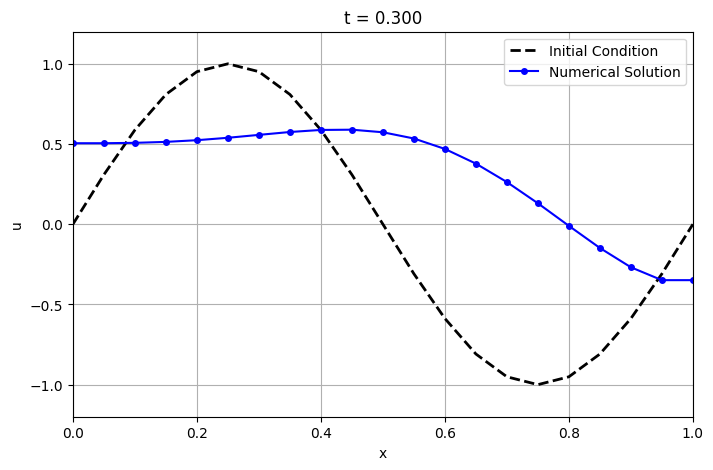

In [99]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8,5))

# Initial condition
init_line, = ax.plot(x, uinit,
                     'k--',
                     lw=2,
                     label='Initial Condition')

# Numerical solution
num_line, = ax.plot([], [],
                    'bo-',
                    markersize=4,
                    label='Numerical Solution')

ax.set_xlim(0, L)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel('x')
ax.set_ylabel('u')

ax.grid(True)
ax.legend()

title = ax.set_title("")

def init():

    num_line.set_data([], [])
    title.set_text("")

    return num_line, title

def animate(frame):

    num_line.set_data(x, sol[frame])

    tframe = frame * dt

    title.set_text(f't = {tframe:.3f}')

    return num_line, title

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=range(0, len(sol), 10),
    init_func=init,
    interval=100,
    blit=True
)

HTML(ani.to_jshtml())

In [100]:
print(np.min(u), np.max(u))

-0.34869972152016193 0.5892487663578695


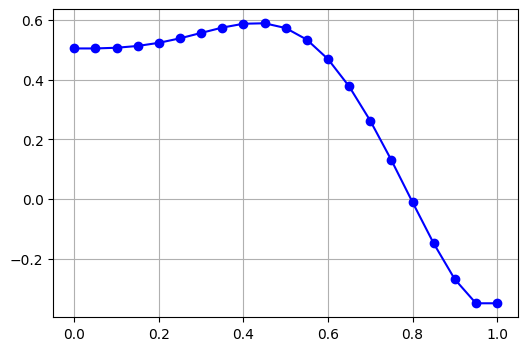

In [101]:
plt.figure(figsize=(6,4))
2
plt.plot(x, sol[-1], 'bo-')
3
plt.grid()
4
plt.show()

# Why a Neumann Boundary Condition Does Not Work Well with a Sine Wave

## The Issue

In the simulation, a zero-gradient Neumann boundary condition is imposed:

    ∂u/∂x = 0

at both boundaries

    x = 0
    x = L

This means that the slope of the solution must be zero at the left and right ends of the domain.

------------------------------------------------------------

## Initial Condition

The chosen initial condition is

    u(x,0) = sin(2πx)

The derivative of this function is

    ∂u/∂x = 2π cos(2πx)

Evaluating at the boundaries:

At x = 0:

    ∂u/∂x = 2π cos(0)
           = 2π

At x = 1:

    ∂u/∂x = 2π cos(2π)
           = 2π

Therefore,

    ∂u/∂x ≠ 0

at both boundaries.

------------------------------------------------------------

## Why This Is a Problem

The Neumann boundary condition requires

    ∂u/∂x = 0

but the sine wave starts with

    ∂u/∂x = 2π

at the boundaries.

Therefore, the initial condition violates the boundary condition.

The numerical solver must immediately modify the solution near the boundaries to force the gradient to become zero.

This causes the original sine wave shape to be distorted from the very first timestep.

------------------------------------------------------------

## What the Code Does

The Neumann BC is implemented as

    unew[0]  = unew[1]
    unew[-1] = unew[-2]

This forces

    (u1 - u0)/dx = 0

and

    (uN-1 - uN-2)/dx = 0

which corresponds to

    ∂u/∂x = 0

at the boundaries.

Since the sine wave does not satisfy this condition, the solver adjusts the boundary values immediately.

------------------------------------------------------------

## Visual Explanation

Sine wave:

         /\
      __/  \__
    _/        \_

Boundary slopes are non-zero.

Neumann BC requires:

    ----------

A horizontal tangent (zero slope) at both ends.

The sine wave and the boundary condition are therefore incompatible.

------------------------------------------------------------

## Better Initial Conditions for Neumann BCs

Functions whose derivative is zero at the boundaries are better choices.

Examples:

    u(x,0) = cos(πx)

or

    u(x,0) = cos(2πx)

For

    u(x,0) = cos(πx)

the derivative is

    ∂u/∂x = -π sin(πx)

At x = 0:

    ∂u/∂x = 0

At x = 1:

    ∂u/∂x = 0

Therefore, the initial condition automatically satisfies the Neumann boundary condition.

------------------------------------------------------------

## Conclusion

The sine wave itself is not wrong.

The problem is that

    sin(2πx)

does not satisfy

    ∂u/∂x = 0

at the boundaries.

As a result, the numerical solver must alter the solution to enforce the Neumann condition, causing the wave to quickly deform and eventually flatten.

For Neumann boundary conditions, cosine functions are generally a better choice because they naturally have zero slope at the domain boundaries.